# EDA - DDI Corpus 2013 Train

Notebook này đọc thư mục train của DDI Corpus, parse các file XML trong `DrugBank` và `MedLine`, rồi thống kê số file, document, sentence, entity, nhãn entity, độ dài câu và phân bố BIO token.

In [40]:
from pathlib import Path
from collections import Counter
import re
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except Exception:
    sns = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 1. Kiểm Tra Đường Dẫn Dataset

In [41]:
CANDIDATE_TRAIN_DIRS = [
    Path("/kaggle/input/datasets/tuantc2306/dataset/DDICorpus/Train"),
    Path("/kaggle/input/dataset/DDICorpus/Train"),
    Path("/kaggle/input/ddicorpus/DDICorpus/Train"),
    Path("/kaggle/input/DDICorpus/Train"),
]

TRAIN_DIR = next((p for p in CANDIDATE_TRAIN_DIRS if p.exists()), None)

if TRAIN_DIR is None:
    print("Không tìm thấy Train dir trong các path mặc định. Một số thư mục dưới /kaggle/input:")
    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir():
            print(p)
    raise FileNotFoundError("Hãy sửa biến TRAIN_DIR thành đúng đường dẫn thư mục Train trên Kaggle.")

print("TRAIN_DIR =", TRAIN_DIR)
print("Các thư mục con:", [p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])

xml_files = sorted(TRAIN_DIR.rglob("*.xml"))
print("Số file XML train:", len(xml_files))
print("Ví dụ file:")
for p in xml_files[:10]:
    print("-", p.relative_to(TRAIN_DIR))

TRAIN_DIR = /kaggle/input/datasets/tuantc2306/dataset/DDICorpus/Train
Các thư mục con: ['MedLine', 'DrugBank']
Số file XML train: 714
Ví dụ file:
- DrugBank/19-norandrostenedione_ddi.xml
- DrugBank/Abarelix_ddi.xml
- DrugBank/Abatacept_ddi.xml
- DrugBank/Abciximab_ddi.xml
- DrugBank/Acamprosate_ddi.xml
- DrugBank/Acarbose_ddi.xml
- DrugBank/Acebutolol_ddi.xml
- DrugBank/Acetazolamide_ddi.xml
- DrugBank/Acetohydroxamic Acid_ddi.xml
- DrugBank/Aciclovir_ddi.xml


## 2. Parse XML Thành DataFrame

In [42]:
TOKEN_RE = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)


def tokenize_with_offsets(text):
    """Tokenize đơn giản, giữ offset để ước lượng BIO label."""
    return [(m.group(), m.start(), m.end() - 1) for m in TOKEN_RE.finditer(text or "")]


def parse_char_offsets(char_offset):
    """DDI dùng charOffset dạng 'start-end' hoặc nhiều span 'start-end;start-end'."""
    spans = []
    if not char_offset:
        return spans
    for part in str(char_offset).split(";"):
        part = part.strip()
        if not part:
            continue
        if "-" in part:
            start, end = part.split("-", 1)
            spans.append((int(start), int(end)))
        else:
            pos = int(part)
            spans.append((pos, pos))
    return spans


def overlaps(a_start, a_end, b_start, b_end):
    return a_start <= b_end and b_start <= a_end


def source_from_path(xml_path):
    rel = xml_path.relative_to(TRAIN_DIR)
    return rel.parts[0] if len(rel.parts) > 1 else "Unknown"


def parse_xml_file(xml_path):
    source = source_from_path(xml_path)
    file_id = xml_path.stem
    root = ET.parse(xml_path).getroot()
    documents = [root] if root.tag == "document" else root.findall(".//document")
    if not documents:
        documents = [root]

    file_rows, doc_rows, sent_rows, ent_rows, pair_rows = [], [], [], [], []
    for doc in documents:
        doc_id = doc.attrib.get("id", file_id)
        sentences = doc.findall(".//sentence")
        doc_entity_count = 0
        doc_pair_count = 0

        for sent in sentences:
            sent_id = sent.attrib.get("id")
            text = sent.attrib.get("text", "")
            tokens = tokenize_with_offsets(text)
            entities = sent.findall("entity")
            pairs = sent.findall("pair")

            sent_rows.append({
                "source": source,
                "file": str(xml_path.relative_to(TRAIN_DIR)),
                "document_id": doc_id,
                "sentence_id": sent_id,
                "text": text,
                "char_len": len(text),
                "token_count": len(tokens),
                "entity_count": len(entities),
                "pair_count": len(pairs),
            })

            for ent in entities:
                ent_id = ent.attrib.get("id")
                ent_text = ent.attrib.get("text", "")
                ent_type = ent.attrib.get("type", "UNKNOWN")
                char_offset = ent.attrib.get("charOffset", "")
                spans = parse_char_offsets(char_offset)
                ent_rows.append({
                    "source": source,
                    "file": str(xml_path.relative_to(TRAIN_DIR)),
                    "document_id": doc_id,
                    "sentence_id": sent_id,
                    "entity_id": ent_id,
                    "entity_text": ent_text,
                    "entity_text_lower": ent_text.lower(),
                    "entity_type": ent_type,
                    "charOffset": char_offset,
                    "span_count": len(spans),
                    "char_start": min([s for s, _ in spans], default=np.nan),
                    "char_end": max([e for _, e in spans], default=np.nan),
                    "span_char_len": sum(e - s + 1 for s, e in spans),
                })

            for pair in pairs:
                pair_rows.append({
                    "source": source,
                    "file": str(xml_path.relative_to(TRAIN_DIR)),
                    "document_id": doc_id,
                    "sentence_id": sent_id,
                    "pair_id": pair.attrib.get("id"),
                    "e1": pair.attrib.get("e1"),
                    "e2": pair.attrib.get("e2"),
                    "ddi": pair.attrib.get("ddi"),
                    "pair_type": pair.attrib.get("type", "none"),
                })

            doc_entity_count += len(entities)
            doc_pair_count += len(pairs)

        doc_rows.append({
            "source": source,
            "file": str(xml_path.relative_to(TRAIN_DIR)),
            "document_id": doc_id,
            "sentence_count": len(sentences),
            "entity_count": doc_entity_count,
            "pair_count": doc_pair_count,
        })

    rel_file = str(xml_path.relative_to(TRAIN_DIR))
    file_rows.append({
        "source": source,
        "file": rel_file,
        "document_count": len(documents),
        "sentence_count": sum(r["sentence_count"] for r in doc_rows if r["file"] == rel_file),
        "entity_count": sum(r["entity_count"] for r in doc_rows if r["file"] == rel_file),
        "pair_count": sum(r["pair_count"] for r in doc_rows if r["file"] == rel_file),
    })
    return file_rows, doc_rows, sent_rows, ent_rows, pair_rows


all_file_rows, all_doc_rows, all_sent_rows, all_ent_rows, all_pair_rows = [], [], [], [], []
bad_files = []

for xml_path in xml_files:
    try:
        file_rows, doc_rows, sent_rows, ent_rows, pair_rows = parse_xml_file(xml_path)
        all_file_rows.extend(file_rows)
        all_doc_rows.extend(doc_rows)
        all_sent_rows.extend(sent_rows)
        all_ent_rows.extend(ent_rows)
        all_pair_rows.extend(pair_rows)
    except Exception as exc:
        bad_files.append({"file": str(xml_path), "error": repr(exc)})

file_df = pd.DataFrame(all_file_rows)
doc_df = pd.DataFrame(all_doc_rows)
sent_df = pd.DataFrame(all_sent_rows)
entity_df = pd.DataFrame(all_ent_rows)
pair_df = pd.DataFrame(all_pair_rows)
bad_df = pd.DataFrame(bad_files)

print("file_df:", file_df.shape)
print("doc_df:", doc_df.shape)
print("sent_df:", sent_df.shape)
print("entity_df:", entity_df.shape)
print("pair_df:", pair_df.shape)
print("bad_df:", bad_df.shape)

file_df: (714, 6)
doc_df: (714, 6)
sent_df: (6976, 9)
entity_df: (14765, 13)
pair_df: (27792, 9)
bad_df: (0, 0)


In [43]:
file_df.head(5)

,source,file,document_count,sentence_count,entity_count,pair_count
0,DrugBank,DrugBank/19-norandrostenedione_ddi.xml,1,1,0,0
1,DrugBank,DrugBank/Abarelix_ddi.xml,1,6,6,1
2,DrugBank,DrugBank/Abatacept_ddi.xml,1,6,25,81
3,DrugBank,DrugBank/Abciximab_ddi.xml,1,5,16,35
4,DrugBank,DrugBank/Acamprosate_ddi.xml,1,7,21,31


In [44]:
doc_df.head(5)

,source,file,document_id,sentence_count,entity_count,pair_count
0,DrugBank,DrugBank/19-norandrostenedione_ddi.xml,DDI-DrugBank.d436,1,0,0
1,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,6,6,1
2,DrugBank,DrugBank/Abatacept_ddi.xml,DDI-DrugBank.d297,6,25,81
3,DrugBank,DrugBank/Abciximab_ddi.xml,DDI-DrugBank.d532,5,16,35
4,DrugBank,DrugBank/Acamprosate_ddi.xml,DDI-DrugBank.d0,7,21,31


In [45]:
sent_df.head(5)

,source,file,document_id,sentence_id,text,char_len,token_count,entity_count,pair_count
0,DrugBank,DrugBank/19-norandrostenedione_ddi.xml,DDI-DrugBank.d436,DDI-DrugBank.d436.s0,"No drug, nutritional supplement, food or herb interactions have yet been reported.",82,15,0,0
1,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s0,No formal drug/drug interaction studies with Plenaxis were performed.,69,12,1,0
2,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s1,Cytochrome P-450 is not known to be involved in the metabolism of Plenaxis.,75,16,1,0
3,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s2,Plenaxis is highly bound to plasma proteins (96 to 99%).,56,14,1,0
4,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s3,Laboratory Tests Response to Plenaxis should be monitored by measuring serum total testosterone concentrations just prior to administration on Day 29 and ev...,179,27,2,1


In [46]:
entity_df.head(5)

,source,file,document_id,sentence_id,entity_id,entity_text,entity_text_lower,entity_type,charOffset,span_count,char_start,char_end,span_char_len
0,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s0,DDI-DrugBank.d519.s0.e0,Plenaxis,plenaxis,brand,45-52,1,45,52,8
1,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s1,DDI-DrugBank.d519.s1.e0,Plenaxis,plenaxis,brand,66-73,1,66,73,8
2,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s2,DDI-DrugBank.d519.s2.e0,Plenaxis,plenaxis,brand,0-7,1,0,7,8
3,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s3,DDI-DrugBank.d519.s3.e0,Plenaxis,plenaxis,brand,29-36,1,29,36,8
4,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s3,DDI-DrugBank.d519.s3.e1,testosterone,testosterone,drug,83-94,1,83,94,12


In [47]:
pair_df.head(5)

,source,file,document_id,sentence_id,pair_id,e1,e2,ddi,pair_type
0,DrugBank,DrugBank/Abarelix_ddi.xml,DDI-DrugBank.d519,DDI-DrugBank.d519.s3,DDI-DrugBank.d519.s3.p0,DDI-DrugBank.d519.s3.e0,DDI-DrugBank.d519.s3.e1,false,none
1,DrugBank,DrugBank/Abatacept_ddi.xml,DDI-DrugBank.d297,DDI-DrugBank.d297.s1,DDI-DrugBank.d297.s1.p0,DDI-DrugBank.d297.s1.e0,DDI-DrugBank.d297.s1.e1,false,none
2,DrugBank,DrugBank/Abatacept_ddi.xml,DDI-DrugBank.d297,DDI-DrugBank.d297.s1,DDI-DrugBank.d297.s1.p1,DDI-DrugBank.d297.s1.e0,DDI-DrugBank.d297.s1.e2,false,none
3,DrugBank,DrugBank/Abatacept_ddi.xml,DDI-DrugBank.d297,DDI-DrugBank.d297.s1,DDI-DrugBank.d297.s1.p2,DDI-DrugBank.d297.s1.e0,DDI-DrugBank.d297.s1.e3,false,none
4,DrugBank,DrugBank/Abatacept_ddi.xml,DDI-DrugBank.d297,DDI-DrugBank.d297.s1,DDI-DrugBank.d297.s1.p3,DDI-DrugBank.d297.s1.e0,DDI-DrugBank.d297.s1.e4,false,none


In [48]:
if len(bad_df):
    display(bad_df.head(20))
else:
    print("Không có file XML lỗi parse.")

Không có file XML lỗi parse.


## 3. Tổng Quan Số Lượng

In [49]:
summary = pd.DataFrame({
    "metric": [
        "xml_files", "documents", "sentences", "entities", "candidate_pairs",
        "sentences_with_entity", "sentences_with_pair", "bad_xml_files",
    ],
    "value": [
        len(file_df), len(doc_df), len(sent_df), len(entity_df), len(pair_df),
        int((sent_df["entity_count"] > 0).sum()) if len(sent_df) else 0,
        int((sent_df["pair_count"] > 0).sum()) if len(sent_df) else 0,
        len(bad_df),
    ]
})
display(summary)

source_summary = (
    file_df.groupby("source", as_index=False)
    .agg(
        xml_files=("file", "count"),
        documents=("document_count", "sum"),
        sentences=("sentence_count", "sum"),
        entities=("entity_count", "sum"),
        candidate_pairs=("pair_count", "sum"),
    )
)
display(source_summary)

,metric,value
0,xml_files,714
1,documents,714
2,sentences,6976
3,entities,14765
4,candidate_pairs,27792
5,sentences_with_entity,5560
6,sentences_with_pair,3789
7,bad_xml_files,0


,source,xml_files,documents,sentences,entities,candidate_pairs
0,DrugBank,572,572,5675,12929,26005
1,MedLine,142,142,1301,1836,1787


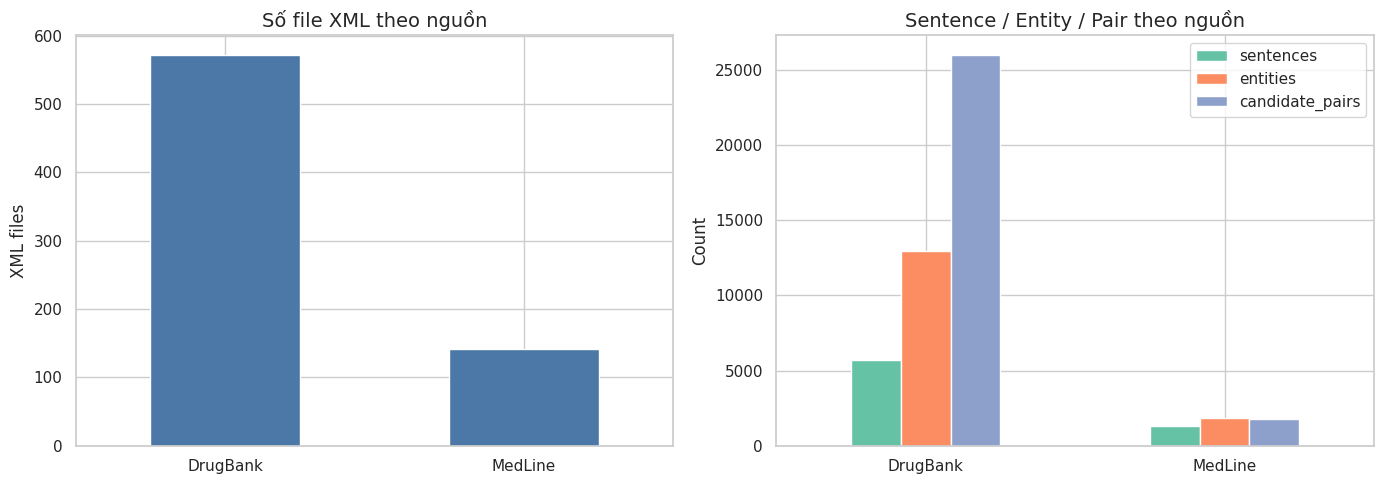

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_summary.plot(x="source", y="xml_files", kind="bar", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("Số file XML theo nguồn")
axes[0].set_xlabel("")
axes[0].set_ylabel("XML files")
axes[0].tick_params(axis="x", rotation=0)

source_summary.plot(x="source", y=["sentences", "entities", "candidate_pairs"], kind="bar", ax=axes[1])
axes[1].set_title("Sentence / Entity / Pair theo nguồn")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. Thống Kê Entity

In [51]:
entity_type_counts = entity_df["entity_type"].value_counts().rename_axis("entity_type").reset_index(name="count")
entity_type_counts["percent"] = entity_type_counts["count"] / entity_type_counts["count"].sum() * 100
display(entity_type_counts)

entity_by_source = pd.crosstab(entity_df["source"], entity_df["entity_type"], margins=True)
display(entity_by_source)

,entity_type,count,percent
0,drug,9425,63.833390
1,group,3399,23.020657
2,brand,1437,9.732475
3,drug_n,504,3.413478


entity_type,brand,drug,drug_n,group,All
source,,,,,
DrugBank,1423,8197,103,3206,12929
MedLine,14,1228,401,193,1836
All,1437,9425,504,3399,14765


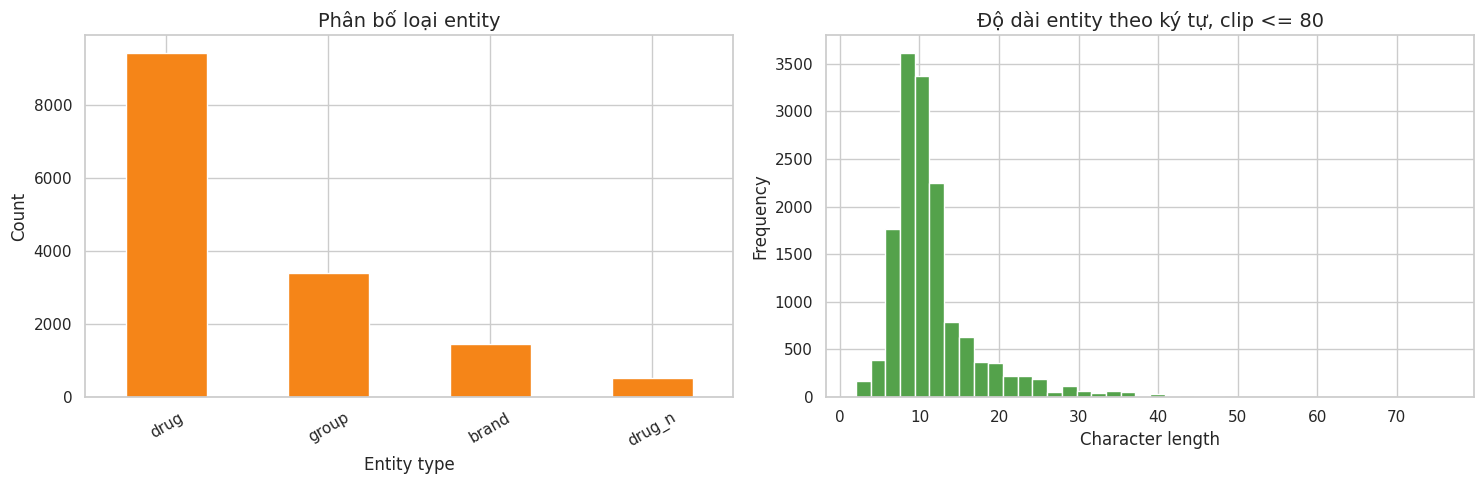

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

entity_type_counts.plot(x="entity_type", y="count", kind="bar", ax=axes[0], legend=False, color="#F58518")
axes[0].set_title("Phân bố loại entity")
axes[0].set_xlabel("Entity type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

if len(entity_df):
    entity_df["span_char_len"].clip(upper=80).hist(bins=40, ax=axes[1], color="#54A24B")
axes[1].set_title("Độ dài entity theo ký tự, clip <= 80")
axes[1].set_xlabel("Character length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [53]:
top_entities = (
    entity_df.groupby(["entity_text_lower", "entity_type"], as_index=False)
    .size()
    .rename(columns={"size": "count"})
    .sort_values("count", ascending=False)
)
display(top_entities.head(30))

,entity_text_lower,entity_type,count
882,digoxin,drug,242
2398,warfarin,drug,220
1832,phenytoin,drug,212
2219,theophylline,drug,153
1350,ketoconazole,drug,151
1408,lithium,drug,149
678,cimetidine,drug,133
574,carbamazepine,drug,110
104,alcohol,drug,107
380,aspirin,brand,101


## 5. Thống Kê Sentence Và Document

In [54]:
display(sent_df[["token_count", "char_len", "entity_count", "pair_count"]].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T)
display(doc_df[["sentence_count", "entity_count", "pair_count"]].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
token_count,6976.0,22.501864,14.347185,0.0,13.0,20.0,29.0,40.0,49.00,67.0,170.0
char_len,6976.0,132.377724,79.365285,0.0,81.0,124.0,174.0,230.0,271.25,364.5,1010.0
entity_count,6976.0,2.116542,2.367590,0.0,1.0,2.0,3.0,4.0,6.00,10.0,55.0
pair_count,6976.0,3.983945,28.244560,0.0,0.0,1.0,3.0,6.0,15.00,45.0,1485.0


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
sentence_count,714.0,9.770308,11.455893,1.0,3.0,6.0,12.0,22.7,31.00,49.00,98.0
entity_count,714.0,20.679272,24.738508,0.0,5.0,12.0,27.0,49.0,73.35,118.00,189.0
pair_count,714.0,38.924370,109.365055,0.0,3.0,13.0,40.0,92.7,131.35,291.16,1818.0


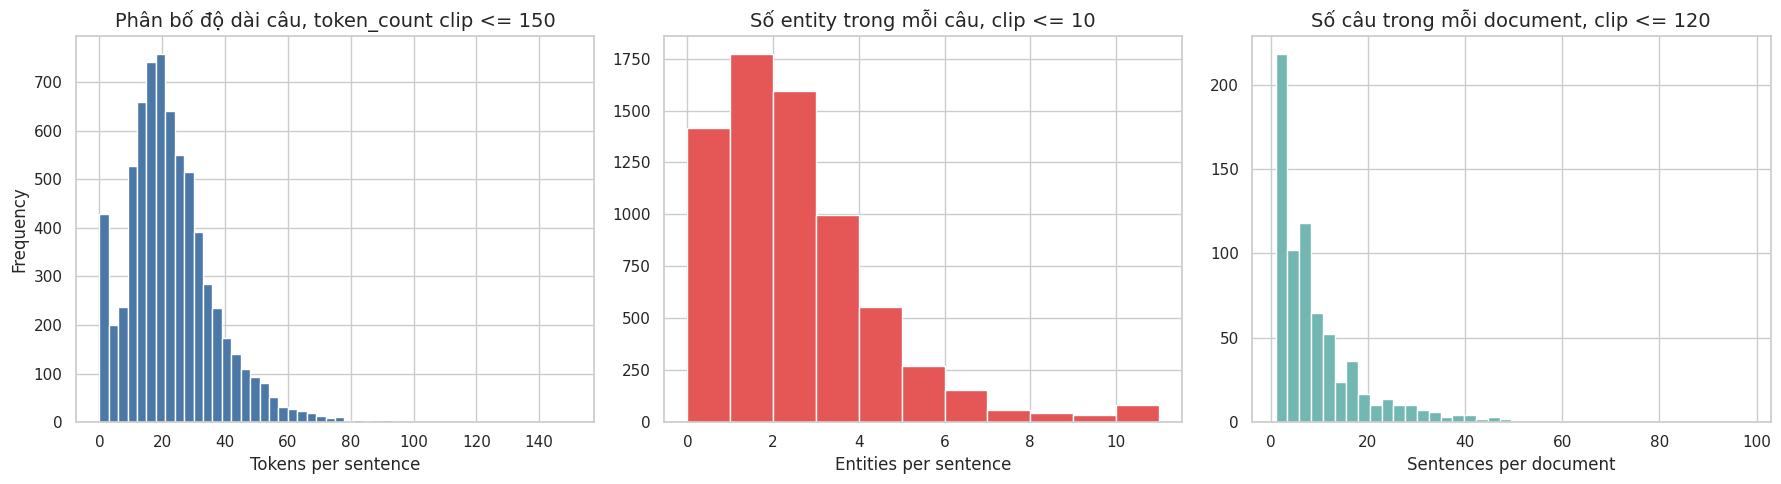

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sent_df["token_count"].clip(upper=150).hist(bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Phân bố độ dài câu, token_count clip <= 150")
axes[0].set_xlabel("Tokens per sentence")
axes[0].set_ylabel("Frequency")

sent_df["entity_count"].clip(upper=10).hist(bins=range(0, 12), ax=axes[1], color="#E45756")
axes[1].set_title("Số entity trong mỗi câu, clip <= 10")
axes[1].set_xlabel("Entities per sentence")

doc_df["sentence_count"].clip(upper=120).hist(bins=40, ax=axes[2], color="#72B7B2")
axes[2].set_title("Số câu trong mỗi document, clip <= 120")
axes[2].set_xlabel("Sentences per document")

plt.tight_layout()
plt.show()

## 6. Ước Lượng Phân Bố BIO Token Labels

Phần này gán BIO label xấp xỉ từ `charOffset` sang token offset. Mục tiêu là xem mất cân bằng nhãn `O` so với các nhãn entity.

In [56]:
entity_by_sentence = {
    sent_id: rows.to_dict("records")
    for sent_id, rows in entity_df.groupby("sentence_id")
} if len(entity_df) else {}

bio_counter = Counter()
token_rows = []

for row in sent_df.itertuples(index=False):
    tokens = tokenize_with_offsets(row.text)
    labels = ["O"] * len(tokens)
    ents = entity_by_sentence.get(row.sentence_id, [])
    ents = sorted(ents, key=lambda x: (x.get("char_start", 10**9), x.get("char_end", 10**9)))

    for ent in ents:
        spans = parse_char_offsets(ent["charOffset"])
        matched_token_ids = []
        for i, (_, tok_start, tok_end) in enumerate(tokens):
            if any(overlaps(tok_start, tok_end, s, e) for s, e in spans):
                matched_token_ids.append(i)
        for j, token_id in enumerate(matched_token_ids):
            prefix = "B" if j == 0 else "I"
            labels[token_id] = f"{prefix}-{ent['entity_type']}"

    bio_counter.update(labels)
    for (tok, start, end), label in zip(tokens, labels):
        token_rows.append({
            "source": row.source,
            "file": row.file,
            "document_id": row.document_id,
            "sentence_id": row.sentence_id,
            "token": tok,
            "start": start,
            "end": end,
            "label": label,
        })

token_df = pd.DataFrame(token_rows)
bio_counts = pd.DataFrame(bio_counter.most_common(), columns=["label", "count"])
bio_counts["percent"] = bio_counts["count"] / bio_counts["count"].sum() * 100

display(bio_counts)
print("Total tokens:", len(token_df))

,label,count,percent
0,O,137699,87.721455
1,B-drug,9425,6.004217
2,B-group,3398,2.164703
3,I-group,2931,1.867200
4,B-brand,1437,0.915444
5,I-drug,884,0.563154
6,I-drug_n,560,0.356749
7,B-drug_n,504,0.321074
8,I-brand,135,0.086002


Total tokens: 156973


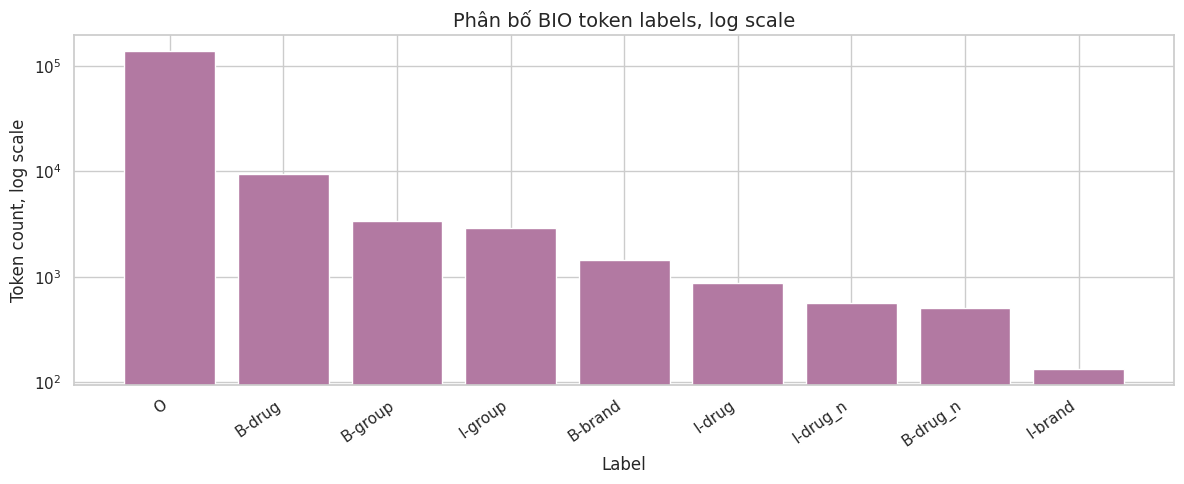

In [57]:
plt.figure(figsize=(12, 5))
plt.bar(bio_counts["label"], bio_counts["count"], color="#B279A2")
plt.yscale("log")
plt.title("Phân bố BIO token labels, log scale")
plt.xlabel("Label")
plt.ylabel("Token count, log scale")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 7. Ví Dụ Dữ Liệu

In [58]:
sample_size = min(8, int((sent_df["entity_count"] > 0).sum())) if len(sent_df) else 0
sample_sentences = sent_df[sent_df["entity_count"] > 0].sample(sample_size, random_state=42) if sample_size else sent_df.head(0)
display(sample_sentences[["source", "file", "sentence_id", "text", "entity_count", "pair_count"]])

display(entity_df[entity_df["sentence_id"].isin(sample_sentences["sentence_id"])][[
    "sentence_id", "entity_id", "entity_text", "entity_type", "charOffset"
]].sort_values(["sentence_id", "charOffset"]))

,source,file,sentence_id,text,entity_count,pair_count
725,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443.s6,Phenobarbital: Decreases aspirin effectiveness by enzyme induction.,2,1
4902,DrugBank,DrugBank/Nadolol_ddi.xml,DDI-DrugBank.d204.s3,"Catecholamine-depleting drugs (e.g., reserpine): additive effect;",1,0
2143,DrugBank,DrugBank/Dicyclomine_ddi.xml,DDI-DrugBank.d543.s7,"Because antacids may interfere with the absorption of anticholinergic agents, simultaneous use of these drugs should be avoided.",2,1
4378,DrugBank,DrugBank/Ketoconazole_ddi.xml,DDI-DrugBank.d458.s14,These agents should not be used in patients treated with NIZORAL Tablets.,1,0
4519,DrugBank,DrugBank/Lansoprazole_ddi.xml,DDI-DrugBank.d431.s11,Lansoprazole causes a profound and long lasting inhibition of gastric acid secretion;,1,0
6237,MedLine,MedLine/11206048.xml,DDI-MedLine.d60.s5,The interaction may be a result of inhibition of both CYP2C9 and 2C19 by fluvoxamine.,2,1
4933,DrugBank,DrugBank/Naproxen_ddi.xml,DDI-DrugBank.d85.s0,The use of NSAIDs in patients who are receiving ACE inhibitors may potentiate renal disease states.,2,1
3487,DrugBank,DrugBank/Fosphenytoin_ddi.xml,DDI-DrugBank.d40.s4,"The pharmacokinetics and protein binding of fosphenytoin, phenytoin, and diazepam were not altered when diazepam and Cerebyx were concurrently administered ...",5,10


,sentence_id,entity_id,entity_text,entity_type,charOffset
11256,DDI-DrugBank.d204.s3,DDI-DrugBank.d204.s3.e0,reserpine,drug,37-45
8256,DDI-DrugBank.d40.s4,DDI-DrugBank.d40.s4.e3,diazepam,drug,104-111
8257,DDI-DrugBank.d40.s4,DDI-DrugBank.d40.s4.e4,Cerebyx,brand,117-123
8253,DDI-DrugBank.d40.s4,DDI-DrugBank.d40.s4.e0,fosphenytoin,drug,44-55
8254,DDI-DrugBank.d40.s4,DDI-DrugBank.d40.s4.e1,phenytoin,drug,58-66
8255,DDI-DrugBank.d40.s4,DDI-DrugBank.d40.s4.e2,diazepam,drug,73-80
10331,DDI-DrugBank.d431.s11,DDI-DrugBank.d431.s11.e0,Lansoprazole,drug,0-11
1671,DDI-DrugBank.d443.s6,DDI-DrugBank.d443.s6.e0,Phenobarbital,drug,0-12
1672,DDI-DrugBank.d443.s6,DDI-DrugBank.d443.s6.e1,aspirin,brand,25-31
10016,DDI-DrugBank.d458.s14,DDI-DrugBank.d458.s14.e0,NIZORAL,brand,57-63


In [59]:
display(token_df[token_df["sentence_id"].isin(sample_sentences["sentence_id"])].head(120))

,source,file,document_id,sentence_id,token,start,end,label
16193,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443,DDI-DrugBank.d443.s6,Phenobarbital,0,12,B-drug
16194,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443,DDI-DrugBank.d443.s6,:,13,13,O
16195,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443,DDI-DrugBank.d443.s6,Decreases,15,23,O
16196,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443,DDI-DrugBank.d443.s6,aspirin,25,31,B-brand
16197,DrugBank,DrugBank/Aspirin_ddi.xml,DDI-DrugBank.d443,DDI-DrugBank.d443.s6,effectiveness,33,45,O
...,...,...,...,...,...,...,...,...
138681,MedLine,MedLine/11206048.xml,DDI-MedLine.d60,DDI-MedLine.d60.s5,The,0,2,O
138682,MedLine,MedLine/11206048.xml,DDI-MedLine.d60,DDI-MedLine.d60.s5,interaction,4,14,O
138683,MedLine,MedLine/11206048.xml,DDI-MedLine.d60,DDI-MedLine.d60.s5,may,16,18,O
138684,MedLine,MedLine/11206048.xml,DDI-MedLine.d60,DDI-MedLine.d60.s5,be,20,21,O


## 8. Lưu Kết Quả EDA Ra `/kaggle/working`

In [60]:
OUT_DIR = Path("/kaggle/working/eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(OUT_DIR / "summary.csv", index=False)
source_summary.to_csv(OUT_DIR / "source_summary.csv", index=False)
file_df.to_csv(OUT_DIR / "files.csv", index=False)
doc_df.to_csv(OUT_DIR / "documents.csv", index=False)
sent_df.to_csv(OUT_DIR / "sentences.csv", index=False)
entity_df.to_csv(OUT_DIR / "entities.csv", index=False)
pair_df.to_csv(OUT_DIR / "pairs.csv", index=False)
token_df.to_csv(OUT_DIR / "tokens_bio_estimated.csv", index=False)
bio_counts.to_csv(OUT_DIR / "bio_label_counts.csv", index=False)
entity_type_counts.to_csv(OUT_DIR / "entity_type_counts.csv", index=False)
top_entities.to_csv(OUT_DIR / "top_entities.csv", index=False)

print("Saved EDA outputs to:", OUT_DIR)
for p in sorted(OUT_DIR.glob("*.csv")):
    print("-", p.name)

Saved EDA outputs to: /kaggle/working/eda_outputs
- bio_label_counts.csv
- documents.csv
- entities.csv
- entity_type_counts.csv
- files.csv
- pairs.csv
- sentences.csv
- source_summary.csv
- summary.csv
- tokens_bio_estimated.csv
- top_entities.csv


## 9. Tóm Tắt Cho Báo Cáo

In [61]:
from IPython.display import Markdown

n_files = int(summary.loc[summary.metric == "xml_files", "value"].iloc[0])
n_docs = int(summary.loc[summary.metric == "documents", "value"].iloc[0])
n_sents = int(summary.loc[summary.metric == "sentences", "value"].iloc[0])
n_ents = int(summary.loc[summary.metric == "entities", "value"].iloc[0])
n_pairs = int(summary.loc[summary.metric == "candidate_pairs", "value"].iloc[0])
avg_tokens = sent_df["token_count"].mean() if len(sent_df) else 0
entity_dist = ", ".join(f"{r.entity_type}: {r['count']}" for _, r in entity_type_counts.iterrows())
o_percent = float(bio_counts.loc[bio_counts.label == "O", "percent"].iloc[0]) if (bio_counts.label == "O").any() else 0

Markdown(f"""
### EDA Summary - Train Set

- Số file XML: **{n_files:,}**
- Số document: **{n_docs:,}**
- Số sentence: **{n_sents:,}**
- Số entity: **{n_ents:,}**
- Số candidate DDI pair: **{n_pairs:,}**
- Độ dài câu trung bình: **{avg_tokens:.2f} tokens/sentence**
- Phân bố entity type: **{entity_dist}**
- Tỉ lệ token nhãn `O` ước lượng: **{o_percent:.2f}%**

Nhận xét: dữ liệu NER thường mất cân bằng mạnh vì phần lớn token là `O`, do đó khi đánh giá mô hình nên dùng entity-level Precision/Recall/F1 thay vì chỉ dùng accuracy.
""")


### EDA Summary - Train Set

- Số file XML: **714**
- Số document: **714**
- Số sentence: **6,976**
- Số entity: **14,765**
- Số candidate DDI pair: **27,792**
- Độ dài câu trung bình: **22.50 tokens/sentence**
- Phân bố entity type: **drug: 9425, group: 3399, brand: 1437, drug_n: 504**
- Tỉ lệ token nhãn `O` ước lượng: **87.72%**

Nhận xét: dữ liệu NER thường mất cân bằng mạnh vì phần lớn token là `O`, do đó khi đánh giá mô hình nên dùng entity-level Precision/Recall/F1 thay vì chỉ dùng accuracy.
